[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter12_seminar_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 12: Machine learning and deep learning for time series

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 12; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.
- Data: Romanian hourly load from Energy-Charts (ENTSO-E transparency data, public API); Eurostat HICP of the 27 EU countries; the Oxford-Man realized library v0.3 (downloaded by `read_omi` from the Internet Archive copy) and our Binance realised measures (`data/realized` of the ATS repository); the M4 hourly series and the official M4 evaluation file (M4-methods repository).
- PyTorch runs on the CPU with small networks and fixed seeds; results can differ slightly across PyTorch versions.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_12'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# PyTorch, scikit-learn and openpyxl are preinstalled in Colab
# !pip install torch scikit-learn openpyxl

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
# local copy of the Oxford-Man realized library, if present (not distributed; read_omi downloads it)
REALIZED_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                     if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
END = '2026-09-18'          # last day of the saved data
# Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and Sheppard 2009): the last public
# file (28 February 2022), preserved by the Internet Archive; six indices and the main measures
OMI_URL = ('https://web.archive.org/web/20220301022212id_/'
           'https://realized.oxford-man.ox.ac.uk/images/oxfordmanrealizedvolatilityindices.zip')
OMI_FILE = 'omi_realized_library_v03.csv'
OMI_SYMBOLS = ['.SPX', '.GDAXI', '.FTSE', '.N225', '.STOXX50E', '.FCHI']
OMI_COLS = ['rv5', 'rv5_ss', 'rv10', 'bv', 'bv_ss', 'medrv', 'rk_parzen', 'rk_twoscale', 'rsv', 'open_to_close',
            'close_price', 'open_price', 'nobs']

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_omi(symbols=None, local=True):
    """Oxford-Man Institute's realized library, version 0.3: daily realised measures (OMI_COLS) of six indices
    (OMI_SYMBOLS), columns date, symbol and the measures, sorted by symbol and date. The library is not
    redistributed with the course: a local copy data/realized/omi_realized_library_v03.csv is used if present,
    otherwise the last public file (Internet Archive copy of 28 February 2022) is downloaded once, the six indices
    are extracted and cached in the temporary folder. Cite: Heber, G., Lunde, A., Shephard, N. and Sheppard, K.
    (2009), Oxford-Man Institute's realized library, version 0.3, Oxford-Man Institute, University of Oxford."""
    import tempfile
    import zipfile
    if 'omi' not in _CACHE:
        cache = os.path.join(tempfile.gettempdir(), 'ats_omi')
        cands = ([os.path.join(REALIZED_DIR, OMI_FILE)] if (local and REALIZED_DIR) else []) + [os.path.join(cache, OMI_FILE)]
        path = next((c for c in cands if os.path.exists(c)), '')
        if not path:
            print("Downloading the Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and "
                  "Sheppard 2009), last public file of 28 February 2022, from the Internet Archive")
            os.makedirs(cache, exist_ok=True)
            zpath = os.path.join(cache, 'oxfordmanrealizedvolatilityindices.zip')
            if not os.path.exists(zpath):
                req = urllib.request.Request(OMI_URL, headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req, timeout=300) as r:
                    raw = r.read()
                with open(zpath, 'wb') as f:
                    f.write(raw)
            with zipfile.ZipFile(zpath) as z:
                d = pd.read_csv(z.open(z.namelist()[0]))
            d = d.rename(columns={d.columns[0]: 'date'})
            d['date'] = pd.to_datetime(d['date'].str[:10])
            d = d[d['Symbol'].isin(OMI_SYMBOLS)][['date', 'Symbol'] + OMI_COLS].rename(columns={'Symbol': 'symbol'})
            path = os.path.join(cache, OMI_FILE)
            d.sort_values(['symbol', 'date']).to_csv(path, index=False, float_format='%.6g')
        _CACHE['omi'] = pd.read_csv(path, parse_dates=['date'])
    d = _CACHE['omi']
    if symbols is not None:
        d = d[d['symbol'].isin([symbols] if isinstance(symbols, str) else list(symbols))]
    return d.copy()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- The engine of Chapter 12, the data helpers and the functions of the solved tasks.

In [ ]:
import io
import sys
import math
import itertools
import urllib.error
try:                                            # PyTorch is preinstalled in Colab
    import torch
    from torch import nn
    TORCH = True
except ImportError:
    import types
    torch = None
    nn = types.SimpleNamespace(Module=object)
    TORCH = False
SEED = 2026
REAL_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/realized/'
REAL_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                 if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
OMI_NAMES = {'.SPX': 'S&P 500', '.GDAXI': 'DAX', '.FTSE': 'FTSE 100', '.N225': 'Nikkei 225', '.STOXX50E': 'Euro Stoxx 50', '.FCHI': 'CAC 40'}
LOAD_API = 'https://api.energy-charts.info/public_power?country=ro&start={a}&end={b}'
LOAD_YEARS = (2023, 2024, 2025, 2026)
LOAD_END = '2026-09-30'
LOAD_EVAL = '2025-01-01'
EU27 = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
HICP = ('prc_hicp_minr', 'M.RCH_A.TOTAL.')
INFL = {'start': '2000-01-01', 'first': '2015-01-01', 'win': 120, 'lags': (1, 2, 3, 6, 12, 18, 24, 36), 'x_lags': 3}
M4_RAW = 'https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset/'
M4H = {'H': 48, 'm': 24, 'L': 336}
ZENG = {'L': 336, 'horizons': (96, 336), 'split': (0.7, 0.1, 0.2)}
RV = {'lags': 22, 'first': 2500, 'refit': 500, 'horizons': (1, 5, 22)}
TAUS9 = np.arange(1, 10) / 10
MONO = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
DEEPAR_LAGS = (1, 24, 168)
_MEM = {}
A1 = {'z': (2.0, -0.6, 0.3, 1.2), 'lam': 0.5}
A2 = {'z': (2.0, -0.6, 0.3, 1.2), 'lam': 0.5, 'alpha': 0.5, 'gamma': 1.0}
A3 = {'sigma2': 1.0, 'rho': 0.3, 'B': (1, 10, 100), 'tol': 0.05}
A4 = {'nu': 0.1, 'M': (10, 50)}
A5 = {'w': 0.9, 'h': 0.5, 'lags': (10, 50)}
A6 = {'biases': (0.0, 1.0, 3.0), 'lag': 50}
A7 = {'K': ((1.0, 0.0), (0.0, 1.0), (1.0, 1.0)), 'V': (1.0, 2.0, 3.0), 'q': (1.0, 1.0)}
A8 = {'Ws': (0.2, 0.3, 0.5), 'Wt': (0.1, 0.1, 0.8)}
PEAK = 19


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def get_bytes(url):
    """Download a public file once per session (no key); optional local cache folder in ATS_CACHE."""
    import hashlib
    import time
    if url in _MEM:
        return _MEM[url]
    cache = os.environ.get('ATS_CACHE')
    path = os.path.join(cache, hashlib.md5(url.encode()).hexdigest()) if cache else None
    if path and os.path.exists(path):
        _MEM[url] = open(path, 'rb').read()
        return _MEM[url]
    for attempt in range(6):                    # the Energy-Charts API limits the request rate
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (ATS course)'})
            _MEM[url] = urllib.request.urlopen(req, timeout=180).read()
            break
        except urllib.error.HTTPError as e:
            if e.code != 429 or attempt == 5:
                raise
            time.sleep(15 * (attempt + 1))
    if path:
        os.makedirs(cache, exist_ok=True)
        open(path, 'wb').write(_MEM[url])
    return _MEM[url]


def read_realized(fname, **kw):
    """A file of data/realized: local copy of the course data, otherwise the ATS repository on GitHub."""
    p = os.path.join(REAL_DIR, fname) if REAL_DIR else ''
    return pd.read_csv(p if p and os.path.exists(p) else REAL_RAW + fname, **kw)


def omi(symbol='.SPX', col='rv5'):
    """Oxford-Man realized library v0.3 (Heber, Lunde, Shephard and Sheppard 2009): daily 5-minute realised variance
    of one index, in %^2; non-positive days dropped."""
    if 'omi' not in _MEM:
        _MEM['omi'] = read_omi()
    d = _MEM['omi']
    s = d[d['symbol'] == symbol].set_index('date').sort_index()[col] * 1e4
    return s[s > 0].dropna().rename(OMI_NAMES[symbol])


def ro_load_hourly():
    """Romanian hourly electricity load (GW), local time, 2023 to LOAD_END (Energy-Charts, ENTSO-E transparency data):
    15-minute values averaged within each hour; a days x 24 table (DST days: 23 or 25 hours become 24)."""
    import json as _json
    if 'load' in _MEM:
        return _MEM['load']
    parts = []
    for y in LOAD_YEARS:
        b = min(f'{y}-12-31', LOAD_END)
        d = _json.loads(get_bytes(LOAD_API.format(a=f'{y}-01-01', b=b)))
        load = [x for x in d['production_types'] if x['name'] == 'Load'][0]['data']
        parts.append(pd.Series(load, index=pd.to_datetime(d['unix_seconds'], unit='s', utc=True), dtype=float))
    s = pd.concat(parts).sort_index()
    s = s[~s.index.duplicated()].tz_convert('Europe/Bucharest')
    df = pd.DataFrame({'y': s.values, 'day': s.index.tz_localize(None).normalize(), 'hour': s.index.hour})
    tab = df.groupby(['day', 'hour'])['y'].mean().unstack('hour')
    tab = tab.interpolate(axis=1, limit_direction='both').interpolate(axis=0, limit_direction='both')
    _MEM['load'] = tab.loc[:LOAD_END] / 1000.0
    return _MEM['load']


def orthodox_easter(y):
    """Orthodox Easter (Gregorian date): Meeus' Julian algorithm plus 13 days (valid 1900-2099)."""
    a, b, c = y % 4, y % 7, y % 19
    d = (19 * c + 15) % 30
    e = (2 * a + 4 * b - d + 34) % 7
    mo, da = divmod(d + e + 114, 31)
    return pd.Timestamp(y, mo, da + 1) + pd.Timedelta(days=13)


def ro_holidays(years):
    """Romanian public holidays: fixed dates, Orthodox Good Friday, Easter and Pentecost (Sunday and Monday)."""
    out = []
    for y in years:
        fixed = ['01-01', '01-02', '01-24', '05-01', '06-01', '08-15', '11-30', '12-01', '12-25', '12-26']
        fixed += ['01-06', '01-07'] if y >= 2024 else []
        out += [pd.Timestamp(f'{y}-{m}') for m in fixed]
        e = orthodox_easter(y)
        out += [e + pd.Timedelta(days=k) for k in (-2, 0, 1, 49, 50)]
    return pd.DatetimeIndex(sorted(set(out)))


def eu_hicp():
    """Annual HICP inflation (%), monthly, of the 27 EU countries (Eurostat prc_hicp_minr, all items), common sample."""
    if 'hicp' in _MEM:
        return _MEM['hicp']
    url = ('https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/' + HICP[0] + '/' + HICP[1] + '+'.join(EU27)
           + '?format=SDMX-CSV&startPeriod=1999-01')
    t = pd.read_csv(io.BytesIO(get_bytes(url)))
    t['date'] = pd.to_datetime(t['TIME_PERIOD'] + '-01')
    P = t.pivot_table(index='date', columns='geo', values='OBS_VALUE')[EU27].loc[INFL['start']:]
    _MEM['hicp'] = P.dropna()
    return _MEM['hicp']


def m4_hourly():
    """The hourly subset of the M4 competition (414 series): training parts (list of arrays) and test parts (414 x 48)."""
    if 'm4' in _MEM:
        return _MEM['m4']
    tr = pd.read_csv(io.BytesIO(get_bytes(M4_RAW + 'Train/Hourly-train.csv')), index_col=0)
    te = pd.read_csv(io.BytesIO(get_bytes(M4_RAW + 'Test/Hourly-test.csv')), index_col=0)
    train = [r.dropna().values.astype(float) for _, r in tr.iterrows()]
    _MEM['m4'] = (train, te.values.astype(float), list(tr.index))
    return _MEM['m4']


def hac_var(x, lags, kernel='bartlett', center=True):
    """Long-run variance of a series: Bartlett (Newey-West) or rectangular (truncated) kernel."""
    x = np.asarray(x, float)
    x = x - x.mean() if center else x
    T = len(x)
    v = x @ x / T
    for k in range(1, lags + 1):
        w = 1 - k / (lags + 1) if kernel == 'bartlett' else 1.0
        v += 2 * w * (x[k:] @ x[:-k]) / T
    return v


def dm_test(d, h=1, kernel='rect', lags=None):
    """Diebold-Mariano test of E[d] = 0 for the loss differential d (model 1 minus model 2), HAC variance with h - 1
    lags (rectangular; Bartlett if negative) and the Harvey-Leybourne-Newbold correction with t(T - 1)."""
    d = np.asarray(d, float)
    d = d[~np.isnan(d)]
    T = len(d)
    L = h - 1 if lags is None else lags
    v = hac_var(d, L, kernel)
    if v <= 0:
        v = hac_var(d, L, 'bartlett')
    dm = d.mean() / np.sqrt(v / T)
    hln = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T) * dm
    return {'T': T, 'dbar': float(d.mean()), 'dm': float(dm), 'hln': float(hln),
            'p_hln': float(2 * stats.t.sf(abs(hln), T - 1))}


def mcs(losses, alpha=0.10, B=2000, block=7, seed=2026):
    """Model Confidence Set (Hansen, Lunde and Nason 2011), T_max statistic, moving-block bootstrap.
    losses: T x m DataFrame; returns the MCS p-value of every model and the set at level alpha."""
    L = np.asarray(losses, float)
    L = L[~np.isnan(L).any(axis=1)]
    T, m = L.shape
    rng = np.random.default_rng(seed)
    nb = int(np.ceil(T / block))
    idx = np.concatenate([np.arange(s, s + block) for s in rng.integers(0, T - block + 1, size=(B, nb)).ravel()])
    idx = idx.reshape(B, nb * block)[:, :T]
    Lb = L[idx].mean(axis=1)
    alive, pvals, p_run = list(range(m)), {}, 0.0
    while len(alive) > 1:
        Lm = L[:, alive].mean(axis=0)
        dbar = Lm - Lm.mean()
        db = Lb[:, alive] - Lb[:, alive].mean(axis=1, keepdims=True)
        se = np.sqrt(((db - dbar) ** 2).mean(axis=0))
        t = dbar / se
        p = float((((db - dbar) / se).max(axis=1) > t.max()).mean())
        p_run = max(p_run, p)
        worst = alive[int(np.argmax(t))]
        pvals[worst] = p_run
        alive.remove(worst)
    pvals[alive[0]] = 1.0
    cols = list(losses.columns) if hasattr(losses, 'columns') else list(range(m))
    out = {cols[i]: pvals[i] for i in range(m)}
    return {'p': out, 'set': [c for c in cols if out[c] >= alpha]}


def qlike(rv, f):
    """QLIKE loss of a variance forecast f for the realised variance rv (Patton 2011)."""
    x = np.asarray(rv, float) / np.asarray(f, float)
    return x - np.log(x) - 1


def pinball(y, q, tau):
    """Pinball (quantile) loss of the tau-quantile forecast q."""
    u = np.asarray(y, float) - np.asarray(q, float)
    return np.maximum(tau * u, (tau - 1) * u)


def smape(y, f):
    """Symmetric MAPE of the M4 competition, in % (Makridakis, Spiliotis and Assimakopoulos 2020)."""
    y, f = np.asarray(y, float), np.asarray(f, float)
    return 200 * np.mean(np.abs(y - f) / (np.abs(y) + np.abs(f)))


def mase(y, f, insample, m):
    """Mean absolute scaled error (Hyndman and Koehler 2006): scale = in-sample MAE of the seasonal naive forecast."""
    x = np.asarray(insample, float)
    return np.mean(np.abs(np.asarray(y, float) - np.asarray(f, float))) / np.mean(np.abs(x[m:] - x[:-m]))


def embed(y, p):
    """Rows t = p, ..., n - 1: X[t] = (y_{t-1}, ..., y_{t-p}), target y_t."""
    y = np.asarray(y, float)
    n = len(y)
    X = np.column_stack([y[p - k:n - k] for k in range(1, p + 1)])
    return X, y[p:]


def ols(Xtr, ytr, Xte):
    """OLS with an intercept: predictions for Xte."""
    A = np.column_stack([np.ones(len(Xtr)), Xtr])
    b = np.linalg.lstsq(A, ytr, rcond=None)[0]
    return np.column_stack([np.ones(len(Xte)), Xte]) @ b


def loocv_ols(X, y):
    """Leave-one-out residuals of OLS with an intercept in closed form, e_i / (1 - h_ii)."""
    A = np.column_stack([np.ones(len(X)), X])
    Q, _ = np.linalg.qr(A)
    h = (Q ** 2).sum(axis=1)
    e = y - Q @ (Q.T @ y)
    return e / (1 - h)


def ar_sim(phi, n, burn=100, rng=None, theta=None, sigma=1.0):
    """Gaussian ARMA path: phi (AR coefficients, any lags), theta (MA coefficients)."""
    rng = rng or np.random.default_rng()
    phi = np.asarray(phi, float)
    theta = np.asarray(theta if theta is not None else [], float)
    e = rng.normal(0, sigma, n + burn)
    x = np.zeros(n + burn)
    p, q = len(phi), len(theta)
    for t in range(n + burn):
        v = e[t]
        for k in range(1, q + 1):
            if t - k >= 0:
                v += theta[k - 1] * e[t - k]
        for k in range(1, p + 1):
            if t - k >= 0:
                v += phi[k - 1] * x[t - k]
        x[t] = v
    return x[burn:]


def random_stationary_ar(p, rng):
    """AR(p) coefficients drawn uniformly on [-1, 1]^p and kept if the process is stationary (rejection sampling)."""
    while True:
        phi = rng.uniform(-1, 1, p)
        if np.all(np.abs(np.roots(np.r_[1.0, -phi])) < 1):
            return phi


def bhk_trial(y, pmax=5, k=5, in_frac=0.7, rng=None):
    """One Monte Carlo trial of Bergmeir, Hyndman and Koo (2018, Section 4): in-set 70%, out-set 30%; AR(1)..AR(pmax)
    by OLS; RMSE estimated by 5-fold CV, LOOCV, non-dependent CV (training rows within pmax lags of a test row
    removed) and OOS (last 20% of the in-set); the 'true' RMSE: model fitted on the whole in-set, one-step forecasts
    of the out-set. Returns a dict model -> procedure -> RMSE."""
    rng = rng or np.random.default_rng()
    y = np.asarray(y, float)
    n = len(y)
    T = int(round(in_frac * n))
    X, z = embed(y, pmax)                           # rows t = pmax..n-1
    tt = np.arange(pmax, n)
    inn = tt < T
    Xi, zi, ti = X[inn], z[inn], tt[inn]
    Xo, zo = X[~inn], z[~inn]
    m = len(zi)
    folds = rng.permutation(np.arange(m) % k)
    n_oos = int(round(0.2 * m))
    out = {}
    for p in range(1, pmax + 1):
        A = Xi[:, :p]
        e5, en = np.empty(m), np.empty(m)
        for f in range(k):
            te = folds == f
            e5[te] = zi[te] - ols(A[~te], zi[~te], A[te])
            far = np.ones(m, bool)
            for t0 in ti[te]:
                far &= np.abs(ti - t0) >= pmax
            en[te] = zi[te] - ols(A[far], zi[far], A[te])
        eo = zi[-n_oos:] - ols(A[:-n_oos], zi[:-n_oos], A[-n_oos:])
        etrue = zo - ols(A, zi, Xo[:, :p])
        r = lambda e: float(np.sqrt(np.mean(e ** 2)))
        out[f'AR({p})'] = {'5-fold CV': r(e5), 'LOOCV': r(loocv_ols(A, zi)), 'nonDepCV': r(en), 'OOS': r(eo),
                           'true': r(etrue)}
    return out


def purged_folds(n, k, gap):
    """Blocked k-fold for rows 0..n-1 with a purge: training rows within `gap` of the test block are removed."""
    edges = np.linspace(0, n, k + 1).astype(int)
    for a, b in zip(edges[:-1], edges[1:]):
        te = np.arange(a, b)
        tr = np.r_[np.arange(0, max(a - gap, 0)), np.arange(min(b + gap, n), n)]
        yield tr, te


def standardise(Xtr, Xte):
    mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0)
    sd = np.where(sd > 0, sd, 1.0)
    return (Xtr - mu) / sd, (Xte - mu) / sd


def penalised_fit(X, y, kind='lasso', keep=(), alphas=None, k=5, gap=12, l1_ratio=0.5, gamma=1.0):
    """Lasso, adaptive lasso (Zou 2006; weights |ridge coefficient|^gamma) or elastic net (Zou and Hastie 2005) on
    standardised features; the columns in `keep` are not penalised (partialled out by OLS, Frisch-Waugh-Lovell).
    The penalty is chosen by blocked k-fold CV with a purge of `gap` rows (h-step targets).
    Returns (intercept, coefficients on the original scale, chosen alpha, selected mask of the penalised columns)."""
    from sklearn.linear_model import ElasticNet, Lasso, Ridge
    X = np.asarray(X, float)
    keep = list(keep)
    pen = [j for j in range(X.shape[1]) if j not in keep]
    K = np.column_stack([np.ones(len(y))] + [X[:, j] for j in keep])
    proj = lambda v: v - K @ np.linalg.lstsq(K, v, rcond=None)[0]
    Xp, yp = proj(X[:, pen]), proj(y)
    sd = Xp.std(axis=0)
    sd = np.where(sd > 0, sd, 1.0)
    Z = Xp / sd
    w = np.ones(len(pen))
    if kind == 'adaptive':
        w = np.abs(Ridge(alpha=1.0).fit(Z, yp).coef_) ** gamma + 1e-8
    Zw = Z * w
    if alphas is None:
        alphas = np.geomspace(1.0, 1e-3, 20) * np.max(np.abs(Zw.T @ yp)) / len(y)

    def model(a):
        if kind == 'enet':
            return ElasticNet(alpha=a, l1_ratio=l1_ratio, max_iter=20000, fit_intercept=False)
        return Lasso(alpha=a, max_iter=20000, fit_intercept=False)
    cv = np.zeros(len(alphas))
    for tr, te in purged_folds(len(y), k, gap):
        for i, a in enumerate(alphas):
            cv[i] += np.sum((yp[te] - model(a).fit(Zw[tr], yp[tr]).predict(Zw[te])) ** 2)
    a = alphas[int(np.argmin(cv))]
    bp = model(a).fit(Zw, yp).coef_ * w / sd
    beta = np.zeros(X.shape[1])
    beta[pen] = bp
    bk = np.linalg.lstsq(K, y - X[:, pen] @ bp, rcond=None)[0]
    beta[keep] = bk[1:]
    return float(bk[0]), beta, float(a), np.abs(bp) > 0


class QRF:
    """Quantile regression forest (Meinshausen 2006): a random forest whose leaves keep all training targets;
    the conditional distribution at x is the weighted empirical distribution with weights
    w_i(x) = (1/B) sum_b 1{x_i in leaf_b(x)} / |leaf_b(x)|."""

    def __init__(self, n_estimators=100, min_samples_leaf=10, max_features=0.5, seed=0):
        from sklearn.ensemble import RandomForestRegressor
        self.rf = RandomForestRegressor(n_estimators=n_estimators, min_samples_leaf=min_samples_leaf,
                                        max_features=max_features, random_state=seed, n_jobs=1)

    def fit(self, X, y):
        self.rf.fit(X, y)
        self.y = np.asarray(y, float)
        self.order = np.argsort(self.y)
        self.leaves = self.rf.apply(X)              # n x B
        return self

    def weights(self, X):
        Lte = self.rf.apply(X)
        n, B = self.leaves.shape
        W = np.zeros((len(X), n))
        for b in range(B):
            lt = self.leaves[:, b]
            cnt = np.bincount(lt)
            same = Lte[:, b][:, None] == lt[None, :]
            W += same / cnt[lt][None, :]
        return W / B

    def predict(self, X):
        return self.rf.predict(X)

    def quantiles(self, X, taus):
        W = self.weights(X)[:, self.order]
        C = np.cumsum(W, axis=1)
        ys = self.y[self.order]
        return np.column_stack([ys[np.minimum((C < t).sum(axis=1), len(ys) - 1)] for t in taus])


def set_seed(seed):
    np.random.seed(seed)
    if TORCH:
        torch.manual_seed(seed)


class MLPNet(nn.Module):
    """Multilayer perceptron: L inputs -> hidden (ReLU) -> H outputs."""

    def __init__(self, L, H, hidden=32, layers=2):
        super().__init__()
        mods, d = [], L
        for _ in range(layers):
            mods += [nn.Linear(d, hidden), nn.ReLU()]
            d = hidden
        self.net = nn.Sequential(*mods, nn.Linear(d, H))

    def forward(self, x):
        return self.net(x)


class RNNNet(nn.Module):
    """Recurrent network (kind = 'rnn', 'lstm' or 'gru') on the input window; the last hidden state is mapped to H outputs."""

    def __init__(self, H, hidden=16, kind='lstm', layers=1):
        super().__init__()
        cell = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[kind]
        self.rnn = cell(1, hidden, num_layers=layers, batch_first=True)
        self.out = nn.Linear(hidden, H)

    def forward(self, x):
        o, _ = self.rnn(x.unsqueeze(-1))
        return self.out(o[:, -1])


class TCNNet(nn.Module):
    """Temporal convolutional network (Bai, Kolter and Koltun 2018): residual blocks of two dilated causal
    convolutions (kernel k, dilations 1, 2, 4, ...); receptive field 1 + 2 (k - 1)(2^levels - 1)."""

    def __init__(self, H, channels=16, k=3, levels=4):
        super().__init__()
        self.k = k
        self.convs = nn.ModuleList()
        self.skips = nn.ModuleList()
        c_in = 1
        for i in range(levels):
            d = 2 ** i
            self.convs.append(nn.ModuleList([nn.Conv1d(c_in, channels, k, dilation=d), nn.Conv1d(channels, channels, k, dilation=d)]))
            self.skips.append(nn.Conv1d(c_in, channels, 1) if c_in != channels else nn.Identity())
            c_in = channels
        self.out = nn.Linear(channels, H)

    def forward(self, x):
        z = x.unsqueeze(1)
        for (c1, c2), sk in zip(self.convs, self.skips):
            d = c1.dilation[0]
            pad = (self.k - 1) * d
            u = torch.relu(c1(nn.functional.pad(z, (pad, 0))))
            u = torch.relu(c2(nn.functional.pad(u, (pad, 0))))
            z = torch.relu(u + sk(z))
        return self.out(z[:, :, -1])


class LinearNet(nn.Module):
    """The linear baselines of Zeng et al. (2023): 'linear' (one layer on the window), 'nlinear' (the last value is
    subtracted and added back), 'dlinear' (moving-average trend + remainder, one linear layer each)."""

    def __init__(self, L, H, kind='dlinear', kernel=25):
        super().__init__()
        self.kind, self.kernel = kind, kernel
        self.lin = nn.Linear(L, H)
        if kind == 'dlinear':
            self.lin_t = nn.Linear(L, H)

    def forward(self, x):
        if self.kind == 'nlinear':
            last = x[:, -1:]
            return self.lin(x - last) + last
        if self.kind == 'dlinear':
            p = (self.kernel - 1) // 2
            xp = torch.cat([x[:, :1].repeat(1, p), x, x[:, -1:].repeat(1, self.kernel - 1 - p)], dim=1)
            trend = xp.unfold(1, self.kernel, 1).mean(-1)
            return self.lin(x - trend) + self.lin_t(trend)
        return self.lin(x)


class PatchTransformer(nn.Module):
    """A small patch Transformer in the spirit of PatchTST (Nie et al. 2023): instance normalisation, non-overlapping
    patches as tokens, learnable positional embedding, encoder layers with multi-head self-attention, a flatten head.
    The attention weights of the last forward pass are kept in self.attn (batch x tokens x tokens, head average)."""

    def __init__(self, L, H, patch=24, d=32, heads=4, layers=1, ff=64):
        super().__init__()
        self.patch, self.n_tok = patch, L // patch
        self.embed = nn.Linear(patch, d)
        self.pos = nn.Parameter(0.02 * torch.randn(1, self.n_tok, d))
        self.att = nn.ModuleList([nn.MultiheadAttention(d, heads, batch_first=True) for _ in range(layers)])
        self.ff = nn.ModuleList([nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Linear(ff, d)) for _ in range(layers)])
        self.n1 = nn.ModuleList([nn.LayerNorm(d) for _ in range(layers)])
        self.n2 = nn.ModuleList([nn.LayerNorm(d) for _ in range(layers)])
        self.head = nn.Linear(self.n_tok * d, H)
        self.attn = None

    def forward(self, x):
        x = x[:, -self.n_tok * self.patch:]
        mu, sd = x.mean(1, keepdim=True), x.std(1, keepdim=True) + 1e-5
        z = ((x - mu) / sd).reshape(len(x), self.n_tok, self.patch)
        z = self.embed(z) + self.pos
        for att, ff, n1, n2 in zip(self.att, self.ff, self.n1, self.n2):
            a, w = att(z, z, z, need_weights=True, average_attn_weights=True)
            self.attn = w.detach()
            z = n1(z + a)
            z = n2(z + ff(z))
        return self.head(z.flatten(1)) * sd + mu


class NBeatsBlock(nn.Module):
    """One N-BEATS block (Oreshkin et al. 2020): a fully connected stack, then linear backcast and forecast.
    pool > 1 and n_coef < H give the N-HiTS block (Challu et al. 2023): max-pooled input and a forecast of n_coef
    coefficients interpolated linearly to H points."""

    def __init__(self, L, H, width=128, layers=3, pool=1, n_coef=None):
        super().__init__()
        self.L, self.H, self.pool = L, H, pool
        self.n_coef = n_coef or H
        mods, d = [], L // pool
        for _ in range(layers):
            mods += [nn.Linear(d, width), nn.ReLU()]
            d = width
        self.fc = nn.Sequential(*mods)
        self.back = nn.Linear(width, L)
        self.fore = nn.Linear(width, self.n_coef)

    def forward(self, x):
        u = x if self.pool == 1 else nn.functional.max_pool1d(x.unsqueeze(1), self.pool, self.pool).squeeze(1)
        h = self.fc(u)
        f = self.fore(h)
        if self.n_coef != self.H:
            f = nn.functional.interpolate(f.unsqueeze(1), size=self.H, mode='linear', align_corners=True).squeeze(1)
        return self.back(h), f


class NBeatsNet(nn.Module):
    """Doubly residual stacking: x_{l+1} = x_l - backcast_l, forecast = sum_l forecast_l. Generic N-BEATS:
    pools = (1, 1, ...); N-HiTS: pools = (8, 4, 1) with n_coefs = (H // 12, H // 4, H)."""

    def __init__(self, L, H, width=128, layers=3, pools=(1, 1, 1), n_coefs=None):
        super().__init__()
        n_coefs = n_coefs or [None] * len(pools)
        self.blocks = nn.ModuleList([NBeatsBlock(L, H, width, layers, p, c) for p, c in zip(pools, n_coefs)])

    def forward(self, x):
        scale = x.abs().mean(1, keepdim=True) + 1e-5     # each window divided by its mean absolute level
        r, f = x / scale, 0.0
        for b in self.blocks:
            bc, fc = b(r)
            r = r - bc
            f = f + fc
        return f * scale


def fit_torch(model, X, Y, epochs=60, lr=1e-3, batch=128, val_frac=0.2, patience=8, seed=0, loss='mse',
              weight_decay=0.0, max_steps=None):
    """Adam on mini-batches; the last val_frac of the (chronological) sample is the validation block for early
    stopping; the weights with the lowest validation loss are kept. loss: 'mse', 'mae' or a callable."""
    set_seed(seed)
    X = torch.as_tensor(np.asarray(X, np.float32))
    Y = torch.as_tensor(np.asarray(Y, np.float32))
    n = len(X)
    nv = int(round(val_frac * n))
    Xt, Yt, Xv, Yv = X[:n - nv], Y[:n - nv], X[n - nv:], Y[n - nv:]
    lf = {'mse': nn.functional.mse_loss, 'mae': nn.functional.l1_loss}.get(loss, loss)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    g = torch.Generator().manual_seed(seed)
    best, best_state, wait, steps = np.inf, None, 0, 0
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xt), generator=g)
        for i in range(0, len(Xt), batch):
            j = perm[i:i + batch]
            opt.zero_grad()
            ls = lf(model(Xt[j]), Yt[j])
            ls.backward()
            opt.step()
            steps += 1
            if max_steps and steps >= max_steps:
                break
        model.eval()
        with torch.no_grad():
            v = float(lf(model(Xv), Yv)) if nv else float(ls)
        if v < best - 1e-7:
            best, wait = v, 0
            best_state = {k: t.clone() for k, t in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
        if max_steps and steps >= max_steps:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


def predict_torch(model, X, batch=4096):
    X = torch.as_tensor(np.asarray(X, np.float32))
    with torch.no_grad():
        return np.concatenate([model(X[i:i + batch]).numpy() for i in range(0, len(X), batch)])


def grad_through_time(kind, T=100, hidden=32, batch=64, seed=0, forget_bias=None):
    """Mean |d h_T / d x_t| (t = 1..T, summed over the units of h_T) for a freshly initialised RNN, LSTM or GRU
    (PyTorch default initialisation), Gaussian inputs: how far back the gradient reaches before any training.
    forget_bias: for the LSTM, the bias of the forget gate (0 at the default initialisation)."""
    set_seed(seed)
    cell = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[kind](1, hidden, batch_first=True)
    if kind == 'lstm' and forget_bias is not None:
        with torch.no_grad():
            cell.bias_ih_l0[hidden:2 * hidden] = forget_bias
            cell.bias_hh_l0[hidden:2 * hidden] = 0.0
    x = torch.randn(batch, T, 1, requires_grad=True)
    o, _ = cell(x)
    o[:, -1].sum().backward()
    return x.grad.abs().squeeze(-1).mean(0).numpy()


class DeepARNet(nn.Module):
    """A DeepAR-type model (Salinas et al. 2020): an LSTM over (scaled lagged targets at lags 1, 24, 168; sin and cos of
    the hour of the day) whose state gives the mean and the standard deviation of a Gaussian for the next scaled value."""

    def __init__(self, hidden=40, layers=2, n_in=len(DEEPAR_LAGS) + 2):
        super().__init__()
        self.lstm = nn.LSTM(n_in, hidden, num_layers=layers, batch_first=True)
        self.mu = nn.Linear(hidden, 1)
        self.sd = nn.Linear(hidden, 1)

    def forward(self, feat, state=None):
        o, state = self.lstm(feat, state)
        return self.mu(o).squeeze(-1), nn.functional.softplus(self.sd(o)).squeeze(-1) + 1e-3, state


def deepar_features(Z, P, j0, j1, lags=DEEPAR_LAGS, period=24):
    """Inputs for the targets at columns j0..j1-1 of the scaled segments Z (batch x length): the lagged values and the
    hour of the day of the target (positions P, same shape as Z)."""
    cols = np.arange(j0, j1)
    lagged = [Z[:, cols - l] for l in lags]
    a = 2 * np.pi * (P[:, cols] % period) / period
    return np.stack(lagged + [np.sin(a), np.cos(a)], -1).astype(np.float32)


def deepar_train(series, C, H, steps=1500, batch=64, lr=1e-3, seed=0, hidden=40, layers=2, lags=DEEPAR_LAGS, checkpoints=()):
    """Train on random segments of length max(lags) + C + H, with the Gaussian log-likelihood of the last C + H values
    given their lagged values (teacher forcing); each segment is divided by 1 + the mean of its context, as in DeepAR.
    checkpoints: steps at which a copy of the weights is kept (returned in net.checkpoints)."""
    set_seed(seed)
    rng = np.random.default_rng(seed)
    net = DeepARNet(hidden, layers, len(lags) + 2)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    M = max(lags)
    S = M + C + H
    ok = [i for i, s in enumerate(series) if len(s) > S]
    saved = {}
    for step in range(1, steps + 1):
        Z, P = [], []
        for i in rng.choice(ok, batch):
            a = rng.integers(0, len(series[i]) - S + 1)
            Z.append(series[i][a:a + S])
            P.append(np.arange(a, a + S))
        Z, P = np.array(Z, np.float32), np.array(P)
        Z = Z / (1 + Z[:, M:M + C].mean(1, keepdims=True))
        mu, sd, _ = net(torch.as_tensor(deepar_features(Z, P, M, S, lags)))
        y = torch.as_tensor(Z[:, M:S])
        nll = (torch.log(sd) + 0.5 * ((y - mu) / sd) ** 2).mean()
        opt.zero_grad()
        nll.backward()
        opt.step()
        if step in checkpoints:
            saved[step] = {k: v.clone() for k, v in net.state_dict().items()}
    net.eval()
    net.checkpoints = saved
    return net


def deepar_sample(net, histories, starts, C, H, n_samples=100, seed=0, lags=DEEPAR_LAGS):
    """Ancestral sampling of H steps after each history (array n x (max(lags) + C), the last values of a series whose
    first value has position `starts`): the LSTM runs over the context with the observed values, then each sampled
    value is fed back. Returns samples n x n_samples x H on the original scale."""
    set_seed(seed)
    Hst = np.asarray(histories, np.float32)
    n, M = len(Hst), max(lags)
    sc = 1 + Hst[:, M:M + C].mean(1, keepdims=True)
    Z = np.zeros((n * n_samples, M + C + H), np.float32)
    Z[:, :M + C] = np.repeat(Hst / sc, n_samples, 0)
    P = np.repeat(np.asarray(starts)[:, None] + np.arange(M + C + H)[None, :], n_samples, 0)
    with torch.no_grad():
        _, _, state = net(torch.as_tensor(deepar_features(Z, P, M, M + C, lags)))
        for k in range(H):
            j = M + C + k
            mu, sd, state = net(torch.as_tensor(deepar_features(Z, P, j, j + 1, lags)), state)
            Z[:, j] = (mu[:, 0] + sd[:, 0] * torch.randn(len(Z))).numpy()
    return Z[:, M + C:].reshape(n, n_samples, H) * sc[:, :, None]


def shapley_groups(predict, X, background, groups):
    """Exact interventional Shapley values of feature groups: v(S) = mean over the background rows of the prediction
    with the features of S taken from x and the others from the background row; phi_g = sum over S without g of
    |S|!(G - |S| - 1)!/G! [v(S + g) - v(S)]. Returns phi (n x G) and the base value v(empty)."""
    X, Bg = np.asarray(X, float), np.asarray(background, float)
    G = len(groups)
    n, nb = len(X), len(Bg)
    v = {}
    for r in range(G + 1):
        for S in itertools.combinations(range(G), r):
            Z = np.repeat(Bg[None], n, 0)
            for g in S:
                Z[:, :, groups[g]] = X[:, None, groups[g]]
            v[S] = predict(Z.reshape(n * nb, -1)).reshape(n, nb).mean(1)
    phi = np.zeros((n, G))
    for g in range(G):
        rest = [j for j in range(G) if j != g]
        for r in range(G):
            for S in itertools.combinations(rest, r):
                w = math.factorial(r) * math.factorial(G - r - 1) / math.factorial(G)
                phi[:, g] += w * (v[tuple(sorted(S + (g,)))] - v[S])
    return phi, float(v[()].mean())


def lagmat(x, p):
    """Columns x_t, x_{t-1}, ..., x_{t-p+1} (NaN at the start)."""
    return np.column_stack([np.r_[np.full(k, np.nan), x[:len(x) - k]] for k in range(p)])


def global_local(h=12, lags=INFL['lags'], win=INFL['win'], first=INFL['first']):
    """Direct h-step forecasts of annual HICP inflation of the 27 EU countries from rolling windows of `win` months:
    local AR(p) (one OLS per country) against global AR(p) (one pooled OLS, the same coefficients for all
    countries; Montero-Manso and Hyndman 2021). Returns squared errors: dict p -> (local, global), each origins x 27."""
    P = eu_hicp()
    Y = P.values
    T, N = Y.shape
    dates = P.index
    o0 = int(np.searchsorted(dates, pd.Timestamp(first)))
    out = {}
    for p in lags:
        L = [lagmat(Y[:, i], p) for i in range(N)]
        el, eg = [], []
        for t in range(o0, T - h):
            rows = np.arange(max(t - win + 1, p - 1), t - h + 1)       # targets y_{s+h} known at t
            Xg, yg = [], []
            fl, fg = np.empty(N), np.empty(N)
            for i in range(N):
                X, y = L[i][rows], Y[rows + h, i]
                fl[i] = ols(X, y, L[i][t:t + 1])[0]
                Xg.append(X)
                yg.append(y)
            Xg, yg = np.vstack(Xg), np.concatenate(yg)
            for i in range(N):
                fg[i] = ols(Xg, yg, L[i][t:t + 1])[0]
            el.append((Y[t + h] - fl) ** 2)
            eg.append((Y[t + h] - fg) ** 2)
        out[p] = (np.array(el), np.array(eg))
    return out, list(P.columns)


def ols_coef(X, y):
    """OLS coefficients with an intercept (first)."""
    A = np.column_stack([np.ones(len(X)), X])
    return np.linalg.lstsq(A, y, rcond=None)[0]


def ro_highdim(h=12, win=INFL['win'], first=INFL['first'], p=INFL['x_lags'], refit=3):
    """Romanian inflation h months ahead from the EU panel on rolling windows of `win` months, re-estimated every
    `refit` months: AR(3) (local benchmark); ridge, lasso, adaptive lasso and elastic net on the 3 own lags (not
    penalised) plus 3 lags of the 26 other countries (78 penalised features; penalty by blocked CV with a purge of h
    months); post-lasso OLS; the global AR(12) of the panel."""
    from sklearn.linear_model import Ridge
    P = eu_hicp()
    Y = P.values
    T, N = Y.shape
    cn = list(P.columns)
    ro = cn.index('RO')
    others = [i for i in range(N) if i != ro]
    Z = np.column_stack([lagmat(Y[:, ro], p)] + [lagmat(Y[:, i], p) for i in others])   # own lags first
    own = list(range(p))
    L12 = [lagmat(Y[:, i], 12) for i in range(N)]
    dates = P.index
    o0 = int(np.searchsorted(dates, pd.Timestamp(first)))
    names = ['AR(3)', 'ridge', 'lasso', 'adaptive lasso', 'elastic net', 'post-lasso OLS', 'global AR(12)']
    F = {k: [] for k in names}
    sel, yv, od = [], [], []
    par = {}
    for t in range(o0, T - h):
        rows = np.arange(max(t - win + 1, 11), t - h + 1)
        X, y, x0 = Z[rows], Y[rows + h, ro], Z[t:t + 1]
        if (t - o0) % refit == 0:
            par = {'AR(3)': ols_coef(X[:, own], y)}
            K = np.column_stack([np.ones(len(y)), X[:, own]])
            Xo = X[:, p:]
            mu, sd = Xo.mean(0), Xo.std(0) + 1e-12
            r = Ridge(alpha=float(len(y))).fit(np.column_stack([X[:, own] * 1e3, (Xo - mu) / sd]), y)   # own lags nearly unpenalised
            par['ridge'] = (r, mu, sd)
            for kind, nm in (('lasso', 'lasso'), ('adaptive', 'adaptive lasso'), ('enet', 'elastic net')):
                a, b, _, s = penalised_fit(X, y, kind, keep=own, gap=h)
                par[nm] = (a, b)
                if kind == 'lasso':
                    par['sel'] = s
                    cols = own + [p + j for j in np.where(s)[0]]
                    par['post-lasso OLS'] = (cols, ols_coef(X[:, cols], y))
            Xg = np.vstack([L12[i][rows] for i in range(N)])
            yg = np.concatenate([Y[rows + h, i] for i in range(N)])
            par['global AR(12)'] = ols_coef(Xg, yg)
        F['AR(3)'].append(np.r_[1.0, x0[0, own]] @ par['AR(3)'])
        r, mu, sd = par['ridge']
        F['ridge'].append(r.predict(np.column_stack([x0[:, own] * 1e3, (x0[:, p:] - mu) / sd]))[0])
        for nm in ('lasso', 'adaptive lasso', 'elastic net'):
            a, b = par[nm]
            F[nm].append(a + x0[0] @ b)
        cols, b = par['post-lasso OLS']
        F['post-lasso OLS'].append(np.r_[1.0, x0[0, cols]] @ b)
        F['global AR(12)'].append(np.r_[1.0, L12[ro][t]] @ par['global AR(12)'])
        sel.append(par['sel'])
        yv.append(Y[t + h, ro])
        od.append(dates[t + h])
    return {k: np.array(v) for k, v in F.items()}, np.array(yv), np.array(sel), od, [cn[i] for i in others]


def load_features(Y):
    """Rows (day d+1, hour h) of the day-ahead problem with data up to day d: load at the same hour on days d, d - 1
    and d - 6, the minimum, maximum and last hour of day d, the hour, the day of the week, a holiday dummy, the
    annual cycle. Returns X, y, day index, hour, feature names."""
    A = Y.values
    days = Y.index
    nD = len(days)
    hol = set(ro_holidays(range(days[0].year, days[-1].year + 1)))
    d1 = np.repeat(np.arange(7, nD), 24)
    hh = np.tile(np.arange(24), nD - 7)
    doy = np.array([days[i].dayofyear for i in d1])
    dow = np.array([days[i].dayofweek for i in d1])
    X = np.column_stack([A[d1 - 1, hh], A[d1 - 2, hh], A[d1 - 7, hh], A[d1 - 1].min(1), A[d1 - 1].max(1), A[d1 - 1, 23],
                         hh, dow, [days[i] in hol for i in d1], [days[i - 1] in hol for i in d1],
                         np.sin(2 * np.pi * doy / 365.25), np.cos(2 * np.pi * doy / 365.25)]).astype(float)
    names = ['load d', 'load d-1', 'load d-6', 'min d', 'max d', 'last hour d', 'hour', 'weekday', 'holiday',
             'holiday d', 'sin year', 'cos year']
    return X, A[d1, hh], d1, hh, names


def rv_windows(y, L):
    """Rows t = L-1..n-1: X[t] = (y_{t-L+1}, ..., y_t) (oldest first)."""
    return np.lib.stride_tricks.sliding_window_view(y, L)


def har_feats(W):
    """HAR regressors from windows of 22 values (oldest first): daily, weekly and monthly means."""
    return np.column_stack([W[:, -1], W[:, -5:].mean(1), W.mean(1)])


def rv_forecasts(rv, models=('HAR', 'MLP', 'LSTM', 'TCN', 'HGB'), horizons=RV['horizons'], first=RV['first'],
                 refit=RV['refit'], seeds=(0,), epochs=60):
    """Expanding-window forecasts of RV_{t+h} (one day, h ahead) from y = log RV: HAR (OLS on the daily, weekly,
    monthly means), an MLP and an LSTM and a TCN on the last 22 values (standardised with the training mean and
    standard deviation; average of the seeds), boosting on the 22 lags. Level forecast exp(m + s^2/2), s^2 the
    training residual variance. Re-estimation every `refit` days from day `first`."""
    from sklearn.ensemble import HistGradientBoostingRegressor as HGB
    y = np.log(np.asarray(rv, float))
    L = RV['lags']
    W = rv_windows(y, L)
    tw = np.arange(L - 1, len(y))                                       # time of the last value of each window
    out = {}
    for h in horizons:
        ok = tw + h < len(y)
        Wh, th = W[ok], tw[ok]
        target = y[th + h]
        rec = {k: np.full(len(th), np.nan) for k in models}
        for o in range(first, len(y) - h, refit):
            tr = th + h <= o                                            # targets known at the origin o
            te = (th >= o) & (th < o + refit)
            if not te.any():
                continue
            mu, sd = Wh[tr].mean(), Wh[tr].std()
            Xtr, Xte, ytr = (Wh[tr] - mu) / sd, (Wh[te] - mu) / sd, (target[tr] - mu) / sd
            for k in models:
                if k == 'HAR':
                    A = har_feats(Wh[tr])
                    b = np.linalg.lstsq(np.column_stack([np.ones(len(A)), A]), target[tr], rcond=None)[0]
                    fi = np.column_stack([np.ones(len(A)), A]) @ b
                    f = np.column_stack([np.ones(te.sum()), har_feats(Wh[te])]) @ b
                    s2 = np.var(target[tr] - fi)
                elif k == 'HGB':
                    m = HGB(max_iter=200, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=50, random_state=SEED)
                    m.fit(Xtr, ytr)
                    f = mu + sd * m.predict(Xte)
                    s2 = np.var(sd * (ytr - m.predict(Xtr)))
                elif TORCH:
                    fs, ss = [], []
                    for s in seeds:
                        net = {'MLP': lambda: MLPNet(L, 1, 32, 2), 'LSTM': lambda: RNNNet(1, 16, 'lstm'),
                               'TCN': lambda: TCNNet(1, 16, 3, 3)}[k]()
                        net = fit_torch(net, Xtr, ytr[:, None], epochs=epochs, lr=2e-3, batch=128, seed=s)
                        fs.append(mu + sd * predict_torch(net, Xte)[:, 0])
                        ss.append(np.var(sd * (ytr - predict_torch(net, Xtr)[:, 0])))
                    f, s2 = np.mean(fs, 0), np.mean(ss)
                else:
                    continue
                rec[k][te] = np.exp(f + s2 / 2)
        keep = ~np.isnan(rec[models[0]])
        out[h] = pd.DataFrame({'t': th[keep], 'rv': np.exp(target[keep]), **{k: v[keep] for k, v in rec.items()}})
    return out


def evaluate_rv(F, base='HAR'):
    """QLIKE of each model, ratio to the base, DM (HLN) statistics against the base and the MCS p-values."""
    out = {}
    for h, d in F.items():
        ms = [c for c in d.columns if c not in ('t', 'rv')]
        Lq = pd.DataFrame({k: qlike(d['rv'], d[k]) for k in ms})
        e = {'T': int(len(d)), 'qlike': {k: float(Lq[k].mean()) for k in ms}}
        e['rel'] = {k: e['qlike'][k] / e['qlike'][base] for k in ms}
        e['dm'] = {k: dm_test(Lq[k] - Lq[base], h) for k in ms if k != base}
        e['mcs'] = mcs(Lq, block=max(h, 5))['p']
        out[str(h)] = e
    return out


def naive2(x, H, m):
    """Naive 2 of M4: seasonal adjustment by classical multiplicative decomposition if the lag-m autocorrelation is
    significant at 90% (|r_m| > 1.645 sqrt((1 + 2 sum_{k<m} r_k^2)/n)), then the naive forecast, then reseasonalise."""
    x = np.asarray(x, float)
    n = len(x)
    xc = x - x.mean()
    r = np.array([xc[k:] @ xc[:n - k] for k in range(m + 1)]) / (xc @ xc)
    seasonal = abs(r[m]) > 1.645 * np.sqrt((1 + 2 * np.sum(r[1:m] ** 2)) / n)
    if not seasonal:
        return np.repeat(x[-1], H)
    ma = pd.Series(x).rolling(m, center=True).mean().rolling(2, center=True).mean().shift(-1).values
    ratio = x / ma
    si = np.array([np.nanmean(ratio[k::m]) for k in range(m)])
    si = si / si.mean()
    s_all = si[np.arange(n) % m]
    adj = x / s_all
    return adj[-1] * si[np.arange(n, n + H) % m]


def m4_windows(train, L, H, per_series=60, seed=0):
    """Training windows of the global models: per_series random windows (input L, output H) from each series."""
    rng = np.random.default_rng(seed)
    X, Y = [], []
    for s in train:
        if len(s) < L + H:
            continue
        for a in rng.integers(0, len(s) - L - H + 1, per_series):
            X.append(s[a:a + L])
            Y.append(s[a + L:a + L + H])
    return np.array(X), np.array(Y)


def m4_global(train, H, L, kind, seeds=(0, 1, 2), epochs=30, per_series=60):
    """Global N-BEATS (generic, three blocks), N-HiTS (pools 8, 4, 1) or DLinear trained on windows of all series,
    each window divided by the mean absolute level of its input; ensemble = median of the seeds."""
    X, Y = m4_windows(train, L, H, per_series)
    sc = np.abs(X).mean(1, keepdims=True)
    Xs, Ys = X / sc, Y / sc
    ctx = np.array([s[-L:] for s in train])
    csc = np.abs(ctx).mean(1, keepdims=True)
    fs = []
    for s in seeds:
        net = {'N-BEATS': lambda: NBeatsNet(L, H, 256, 3, (1, 1, 1)),
               'N-HiTS': lambda: NBeatsNet(L, H, 256, 3, (8, 4, 1), (max(H // 12, 2), H // 4, H)),
               'DLinear': lambda: LinearNet(L, H, 'dlinear')}[kind]()
        perm = np.random.default_rng(s).permutation(len(Xs))
        net = fit_torch(net, Xs[perm], Ys[perm], epochs=epochs, lr=1e-3, batch=512, val_frac=0.1, patience=4, seed=s, loss='mae')
        fs.append(predict_torch(net, ctx / csc) * csc)
    return np.median(fs, 0)


def m4_scores(train, test, F, m):
    """sMAPE and MASE per series and the OWA of each method against Naive 2 (M4 definitions)."""
    out = {}
    for k, f in F.items():
        out[k] = dict(smape=float(np.mean([smape(test[i], f[i]) for i in range(len(train))])),
                      mase=float(np.mean([mase(test[i], f[i], train[i], m) for i in range(len(train))])))
    for k in out:
        out[k]['owa'] = 0.5 * (out[k]['smape'] / out['Naive 2']['smape'] + out[k]['mase'] / out['Naive 2']['mase'])
    return out


def soft(z, t):
    return np.sign(z) * np.maximum(np.abs(z) - t, 0.0)


def a1_lasso_ridge():
    """Orthonormal design: lasso = soft-thresholding of the OLS coefficients z at lambda, ridge = z / (1 + lambda)."""
    z, lam = np.array(A1['z']), A1['lam']
    return dict(lasso=soft(z, lam).tolist(), ridge=(z / (1 + lam)).tolist())


def a3_bagging():
    """Variance of the average of B identically distributed predictors with variance sigma^2 and pairwise correlation
    rho: rho sigma^2 + (1 - rho) sigma^2 / B; the B that brings it within tol of its limit."""
    s2, r = A3['sigma2'], A3['rho']
    v = {str(B): r * s2 + (1 - r) * s2 / B for B in A3['B']}
    return dict(var=v, limit=r * s2, B_needed=int(np.ceil((1 - r) / (A3['tol'] * r))))


def a5_rnn():
    """Scalar RNN h_t = tanh(w h_{t-1} + u x_t): |dh_T/dh_{T-k}| = prod |w| (1 - h^2) <= |w|^k; with |h| = 0.5 on the
    path the factor per step is |w| 0.75."""
    w, h = A5['w'], A5['h']
    return dict(bound={str(k): w ** k for k in A5['lags']}, sat={str(k): (w * (1 - h ** 2)) ** k for k in A5['lags']},
                factor=w * (1 - h ** 2))


def a7_attention():
    """Scaled dot-product attention of one query over three keys (d = 2): weights softmax(q k_j / sqrt(2)), output
    sum_j w_j v_j."""
    K, V, q = np.array(A7['K']), np.array(A7['V']), np.array(A7['q'])
    s = K @ q / np.sqrt(2)
    w = np.exp(s - s.max())
    w = w / w.sum()
    return dict(scores=s.tolist(), weights=w.tolist(), out=float(w @ V))


def cv_estimates(X, z, gap, k=5, fit=None, seed=SEED, in_frac=0.8):
    """RMSE estimates on the first in_frac of the sample (random k-fold, blocked k-fold, blocked k-fold with a purge
    of `gap` rows, the last 20% of the in-set) and the 'true' RMSE: fitted on the in-set (the last `gap` rows
    dropped), evaluated on the rest."""
    n = int(in_frac * len(z))
    Xi, zi = X[:n], z[:n]
    fit = fit or (lambda A, y, B: np.column_stack([np.ones(len(B)), B]) @ np.linalg.lstsq(np.column_stack([np.ones(len(A)), A]), y, rcond=None)[0])
    r = lambda e: float(np.sqrt(np.mean(e ** 2)))
    out = {}
    e = np.empty(n)
    f = np.random.default_rng(seed).permutation(np.arange(n) % k)
    for j in range(k):
        e[f == j] = zi[f == j] - fit(Xi[f != j], zi[f != j], Xi[f == j])
    out['random 5-fold'] = r(e)
    for name, g in (('blocked 5-fold', 0), ('purged 5-fold', gap)):
        e = np.empty(n)
        for tr, te in purged_folds(n, k, g):
            e[te] = zi[te] - fit(Xi[tr], zi[tr], Xi[te])
        out[name] = r(e)
    no = int(0.2 * n)
    out['last 20%'] = r(zi[n - no:] - fit(Xi[:n - no - gap], zi[:n - no - gap], Xi[n - no:]))
    out['true'] = r(z[n + gap:] - fit(Xi[:n - gap], zi[:n - gap], X[n + gap:]))
    return out


def rv_targets(sym, h_mean):
    """log RV windows of 22 values and two targets: next-day log RV and the mean log RV of the next h_mean days."""
    y = np.log(omi(sym).values)
    W = rv_windows(y, 22)
    t = np.arange(21, len(y))
    ok = t + h_mean < len(y)
    W, t = W[ok], t[ok]
    c = np.concatenate([[0.0], np.cumsum(y)])
    return W, y[t + 1], (c[t + h_mean + 1] - c[t + 1]) / h_mean, t


def b1_cv_har(save_it=True):
    """HAR on FTSE 100 log RV: CV estimates against the true error, next-day and 22-day-mean targets."""
    W, z1, z22, _ = rv_targets('.FTSE', 22)
    X = har_feats(W)
    res = {'1': cv_estimates(X, z1, 1), '22': cv_estimates(X, z22, 22)}
    fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
    cols = [st.IDAred, st.MainBlue, st.Forest, st.Amber]
    for ax, (h, r) in zip(axs, res.items()):
        ks = [k for k in r if k != 'true']
        ax.bar(range(len(ks)), [r[k] / r['true'] for k in ks], color=cols)
        ax.axhline(1, color=st.DarkText, ls=':', lw=1)
        ax.set_xticks(range(len(ks)))
        ax.set_xticklabels(ks, rotation=15, fontsize=9)
        ax.set_title('next-day log RV' if h == '1' else 'mean log RV of the next 22 days')
        ax.set_ylabel('estimated / true RMSE')
    plt.tight_layout()
    save('ch12_sem_b1', save_it)
    W_, _, _, t = rv_targets('.FTSE', 22)
    d = omi('.FTSE').index
    return dict(res=res, n=int(len(z1)), split=str(d[int(0.8 * len(z1)) + 21].date()))


def b3_global(save_it=True, h=3, lags=(3, 12, 24)):
    r, cn = global_local(h, lags)
    ro = cn.index('RO')
    out = {}
    for p in lags:
        el, eg = r[p]
        out[str(p)] = dict(local=float(np.sqrt(el.mean())), glob=float(np.sqrt(eg.mean())),
                           local_ro=float(np.sqrt(el[:, ro].mean())), glob_ro=float(np.sqrt(eg[:, ro].mean())),
                           dm_all=dm_test((eg - el).mean(1), h)['hln'], p_all=dm_test((eg - el).mean(1), h)['p_hln'],
                           dm_ro=dm_test(eg[:, ro] - el[:, ro], h)['hln'], p_ro=dm_test(eg[:, ro] - el[:, ro], h)['p_hln'])
    fig, ax = plt.subplots(figsize=(8, 3.6))
    x = np.arange(len(lags))
    ax.bar(x - 0.2, [out[str(p)]['local'] for p in lags], 0.4, color=st.IDAred, label='local AR(p)')
    ax.bar(x + 0.2, [out[str(p)]['glob'] for p in lags], 0.4, color=st.MainBlue, label='global AR(p)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'p = {p}' for p in lags])
    ax.set_ylabel('RMSE, 27 countries, h = 3')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save('ch12_sem_b3', save_it)
    out['T'] = int(r[lags[0]][0].shape[0])
    return out


def peak_data():
    """Rows of the evening-peak hour: the day-ahead features of the lecture without the hour column."""
    Y = ro_load_hourly()
    X, y, d1, hh, names = load_features(Y)
    m = hh == PEAK
    keep = [i for i, nm in enumerate(names) if nm != 'hour']
    return X[m][:, keep], y[m], Y.index[d1[m]], [names[i] for i in keep]


def peak_arx(dates):
    """Expert ARX of Chapter 1 for the peak hour (364-day window, daily refit) with empirical quantiles of its last 182
    errors."""
    Y = ro_load_hourly()
    A = Y.values
    days = Y.index
    dow = np.array([d.dayofweek for d in days])
    mins, maxs, last = A.min(1), A.max(1), A[:, 23]
    h = PEAK
    s0 = int(np.searchsorted(days, pd.Timestamp(LOAD_EVAL)))
    P = np.full(len(days), np.nan)
    for dd in range(s0 - 182, len(days)):
        rows = np.arange(dd - 364, dd)
        Xa = np.column_stack([np.ones(len(rows)), A[rows - 1, h], A[rows - 2, h], A[rows - 7, h], mins[rows - 1], maxs[rows - 1],
                              last[rows - 1], dow[rows] == 0, dow[rows] == 5, dow[rows] == 6])
        b = np.linalg.lstsq(Xa, A[rows, h], rcond=None)[0]
        P[dd] = np.r_[1.0, A[dd - 1, h], A[dd - 2, h], A[dd - 7, h], mins[dd - 1], maxs[dd - 1], last[dd - 1],
                      dow[dd] == 0, dow[dd] == 5, dow[dd] == 6] @ b
    E = A[:, h] - P
    idx = np.searchsorted(days, dates)
    pt = P[idx]
    Q = np.array([P[i] + np.nanquantile(E[i - 182:i], TAUS9) for i in idx])
    return pt, Q


def b5_qrf_peak(save_it=True):
    """Quantile regression forest (monthly refit, all earlier data) against the expert ARX for the evening peak."""
    X, y, dates, names = peak_data()
    ev = dates >= pd.Timestamp(LOAD_EVAL)
    Qq = np.full((len(y), len(TAUS9)), np.nan)
    pq = np.full(len(y), np.nan)
    for s in pd.date_range(LOAD_EVAL, LOAD_END, freq='MS'):
        tr = dates < s
        te = (dates >= s) & (dates < s + pd.offsets.MonthBegin(1))
        q = QRF(200, 5, 0.5, SEED).fit(X[tr], y[tr])
        Qq[te] = q.quantiles(X[te], TAUS9)
        pq[te] = q.predict(X[te])
    pa, Qa = peak_arx(dates[ev])
    yv = y[ev]
    out = {}
    for k, Q, pt in (('QRF', Qq[ev], pq[ev]), ('ARX', Qa, pa)):
        L = np.mean([pinball(yv, Q[:, j], t) for j, t in enumerate(TAUS9)], axis=0)
        out[k] = dict(pin=float(L.mean()), cov=float(np.mean((yv >= Q[:, 0]) & (yv <= Q[:, -1]))),
                      mae=float(np.mean(np.abs(yv - pt))), width=float(np.mean(Q[:, -1] - Q[:, 0])), L=L)
    d = out['QRF'].pop('L') - out['ARX'].pop('L')
    dm = dm_test(d, 1)
    out['dm'] = dict(t=dm['hln'], p=dm['p_hln'])
    out['days'] = int(ev.sum())
    fig, ax = plt.subplots(figsize=(9.5, 3.6))
    w = (dates[ev] >= '2026-01-05') & (dates[ev] < '2026-02-16')
    x = dates[ev][w]
    ax.fill_between(x, Qq[ev][w][:, 0], Qq[ev][w][:, -1], color=st.Teal, alpha=0.35, label='QRF 10%-90%')
    ax.plot(x, Qa[w][:, 0], color=st.IDAred, lw=0.9, ls='--', label='ARX 10% and 90%')
    ax.plot(x, Qa[w][:, -1], color=st.IDAred, lw=0.9, ls='--', label='_')
    ax.plot(x, yv[w], color=st.DarkText, lw=1.3, label='load 19:00-20:00')
    ax.set_ylabel('GW')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    plt.tight_layout()
    save('ch12_sem_b5', save_it)
    return out


def b7_lstm_ftse(save_it=True, seeds=(0, 1, 2)):
    rv = omi('.FTSE')
    F = rv_forecasts(rv, models=('HAR', 'LSTM'), horizons=(1,), seeds=seeds)
    E = evaluate_rv(F)['1']
    d = F[1]
    fig, ax = plt.subplots(figsize=(9.5, 3.6))
    dd = rv.index[d['t'].values.astype(int) + 1]
    w = (dd >= '2020-02-01') & (dd < '2020-07-01')
    ax.semilogy(dd[w], d['rv'][w], color=st.DarkText, lw=1, label='realised variance')
    ax.semilogy(dd[w], d['HAR'][w], color=st.IDAred, lw=1, label='HAR')
    ax.semilogy(dd[w], d['LSTM'][w], color=st.MainBlue, lw=1, label='LSTM')
    ax.set_ylabel('%$^2$')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    plt.tight_layout()
    save('ch12_sem_b7', save_it)
    return dict(qlike=E['qlike'], rel=E['rel']['LSTM'], dm=dict(t=E['dm']['LSTM']['hln'], p=E['dm']['LSTM']['p_hln']),
                T=E['T'], start=str(dd[0].date()), end=str(dd[-1].date()), seeds=len(seeds))

# Part A: derivations and computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: lasso and ridge under an orthonormal design

**Context.** OLS coefficients z = (2.0, -0.6, 0.3, 1.2), X'X = nI, lambda = 0.5.

1. Show that the lasso problem separates and derive soft thresholding.
2. Compute the lasso and the ridge coefficients.
3. Which coefficients does each method set to zero?

**Report:** one derivation; eight numbers; one sentence.

In [8]:
# Solution
print(a1_lasso_ridge())

{'lasso': [1.5, -0.09999999999999998, 0.0, 0.7], 'ridge': [1.3333333333333333, -0.39999999999999997, 0.19999999999999998, 0.7999999999999999]}


**Interpretation of the result.** The lasso subtracts lambda from every coefficient and zeroes the third; ridge shrinks proportionally.

## A2 [Proposed]: adaptive lasso and elastic net

**Context.** The same z, lambda = 0.5. Model: A1.

1. Adaptive lasso with weights 1/|z_j|: thresholds and coefficients.
2. Elastic net with alpha = 0.5.
3. The bias on the largest coefficient for the three methods.

**Report:** eight numbers; four numbers; one sentence.

In [ ]:
# Your code here


## A3 [Solved]: the variance of bagging

**Context.** B trees, variance 1, pairwise correlation 0.3.

1. Derive rho sigma^2 + (1 - rho) sigma^2 / B.
2. The variance for B = 1, 10, 100 and the limit.
3. The B that brings it within 5% of the limit.

**Report:** one derivation; four numbers; one number.

In [10]:
# Solution
print(a3_bagging())

{'var': {'1': 1.0, '10': 0.37, '100': 0.307}, 'limit': 0.3, 'B_needed': 47}


**Interpretation of the result.** Beyond a few dozen trees only decorrelation lowers the variance.

## A4 [Proposed]: boosting as gradient descent

**Context.** Squared loss, shrinkage 0.1, a constant base learner, F_0 = 0. Model: A3.

1. Show that F_M = (1 - (1 - nu)^M) ybar.
2. F_M / ybar for M = 10, 50 and the M needed for 90%.
3. The negative gradient of the pinball loss.

**Report:** one derivation; three numbers; one formula.

In [ ]:
# Your code here


## A5 [Solved]: gradients through a scalar RNN

**Context.** h_t = tanh(w h_{t-1} + u x_t), w = 0.9.

1. The product of derivatives and the bound |w|^k.
2. The bound for k = 10 and 50.
3. The actual factor with |h| = 0.5 and the gradient at k = 10 and 50.

**Report:** one derivation; two numbers; three numbers.

In [12]:
# Solution
print(a5_rnn())

{'bound': {'10': 0.3486784401000001, '50': 0.00515377520732012}, 'sat': {'10': 0.019635308465447344, '50': 2.91869451226162e-09}, 'factor': 0.675}


**Interpretation of the result.** Saturated units speed up the decay; a signal 50 steps back cannot move the weights.

## A6 [Proposed]: the LSTM forget gate

**Context.** Cell path c_t = f c_{t-1} + i c~_t with f = sigmoid(b_f). Model: A5.

1. Show that dc_T/dc_{T-k} = f^k on the direct path.
2. f and f^50 for b_f = 0, 1, 3.
3. Why the default initialisation does not protect against vanishing gradients.

**Report:** one derivation; six numbers; one sentence.

In [ ]:
# Your code here


## A7 [Solved]: attention by hand

**Context.** Keys (1, 0), (0, 1), (1, 1); values (1, 2, 3); query (1, 1); d_k = 2.

1. The scores.
2. The softmax weights and the output.
3. The effect of permuting the tokens.

**Report:** three numbers; four numbers; one sentence.

In [14]:
# Solution
print(a7_attention())

{'scores': [0.7071067811865475, 0.7071067811865475, 1.414213562373095], 'weights': [0.2482550782577231, 0.2482550782577231, 0.5034898434845538], 'out': 2.255234765226831}


**Interpretation of the result.** Attention ignores the order of the tokens unless positions are encoded.

## A8 [Proposed]: DLinear is one linear map

**Context.** L = 3, moving average of length 3 with replicate padding, Ws = (0.2, 0.3, 0.5), Wt = (0.1, 0.1, 0.8). Model: A7.

1. The matrix A.
2. W = Ws (I - A) + Wt A.
3. What it implies for DLinear.

**Report:** a matrix; three numbers; one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: validating HAR on FTSE 100 realised variance

**Question.** Do random and blocked cross-validation estimate the future error of HAR?

1. Random 5-fold, blocked 5-fold, purged 5-fold and last-20% estimates on the in-set.
2. The true RMSE on the last 20% of the sample.
3. The same for the 22-day mean target.
4. Interpretation.

**Report:** ten RMSE values, one sentence.

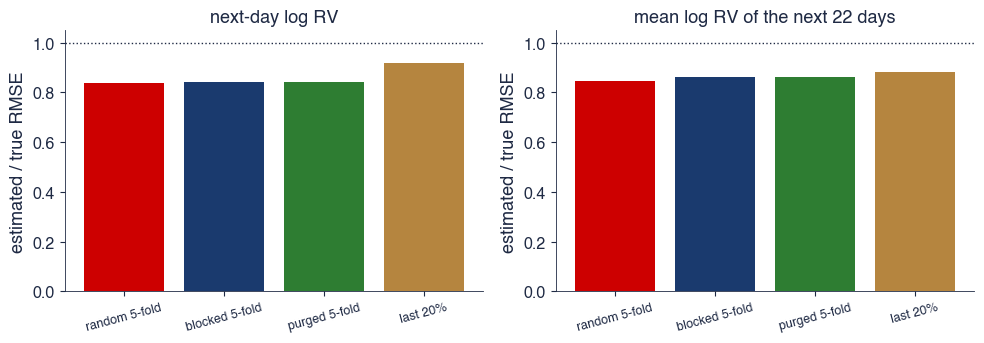

{'res': {'1': {'random 5-fold': 0.5718344819403226, 'blocked 5-fold': 0.5727172755460196, 'purged 5-fold': 0.5727238449055347, 'last 20%': 0.6261674938884765, 'true': 0.6813029638348367}, '22': {'random 5-fold': 0.43375442521997726, 'blocked 5-fold': 0.44223894708172706, 'purged 5-fold': 0.4423491121219959, 'last 20%': 0.45280059945362716, 'true': 0.5135595500107693}}, 'n': 5543, 'split': '2017-09-05'}


In [16]:
# Solution
print(b1_cv_har(save_it=False))

**Interpretation of the result.** Random and blocked agree for next-day targets; random is optimistic for 22-day targets; all miss 2020.

## B2 [Proposed]: a random forest with a time index

**Question.** How much does a time index inflate the optimism of random cross-validation? Model: B1.

1. The four estimates and the true RMSE with lags only.
2. The same with the row number as a feature.
3. Interpretation.

**Report:** ten RMSE values, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: local and global AR for EU inflation

**Question.** Does one AR model for all 27 countries forecast three months ahead better than 27 local ones?

1. Local and global AR(p) for p = 3, 12, 24.
2. RMSE for the 27 countries and Romania.
3. DM of global against local.
4. Interpretation.

**Report:** twelve RMSE values, three DM statistics, one sentence.

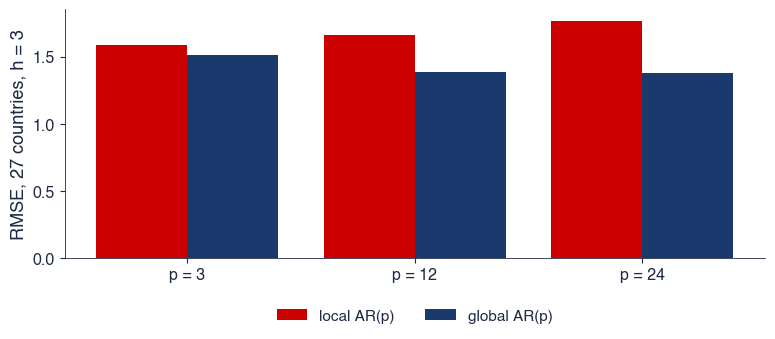

{'3': {'local': 1.5886913977025976, 'glob': 1.5139037608298334, 'local_ro': 1.4628477264189401, 'glob_ro': 1.4976818371075542, 'dm_all': -1.560931098705406, 'p_all': 0.120864020879534, 'dm_ro': 0.9600615975642581, 'p_ro': 0.33872795581742965}, '12': {'local': 1.6600986224927718, 'glob': 1.3856018644067642, 'local_ro': 1.3268327203709158, 'glob_ro': 1.3733205454818302, 'dm_all': -2.2902699810980063, 'p_all': 0.023544406630587697, 'dm_ro': 0.6608708546458738, 'p_ro': 0.5098130734517442}, '24': {'local': 1.7658196458981443, 'glob': 1.3755659006043717, 'local_ro': 1.3953839129465282, 'glob_ro': 1.3721117477618947, 'dm_all': -3.108922475163998, 'p_all': 0.002287381773086071, 'dm_ro': -0.23320317899931928, 'p_ro': 0.8159542648497182}, 'T': 137}


In [18]:
# Solution
print(b3_global(save_it=False))

**Interpretation of the result.** Local AR deteriorates with the memory, global AR improves; the gain is significant at p = 24.

## B4 [Proposed]: the panel lasso for Romania

**Question.** Do the other 26 countries help forecast Romanian inflation three months ahead? Model: B3.

1. Forecasts of the seven models.
2. RMSE and DM against AR(3).
3. The selection summary.
4. Interpretation.

**Report:** seven RMSE values, six DM p-values, the selection summary, one sentence.

In [ ]:
# Your code here


## B5 [Solved]: QRF and ARX for the evening peak

**Question.** Does a quantile regression forest give better day-ahead quantiles than the expert ARX at 19:00-20:00?

1. The deciles of both methods.
2. Pinball, 80% coverage, width, MAE.
3. DM on the daily pinball losses.
4. Interpretation.

**Report:** eight numbers, one DM statistic, one sentence.

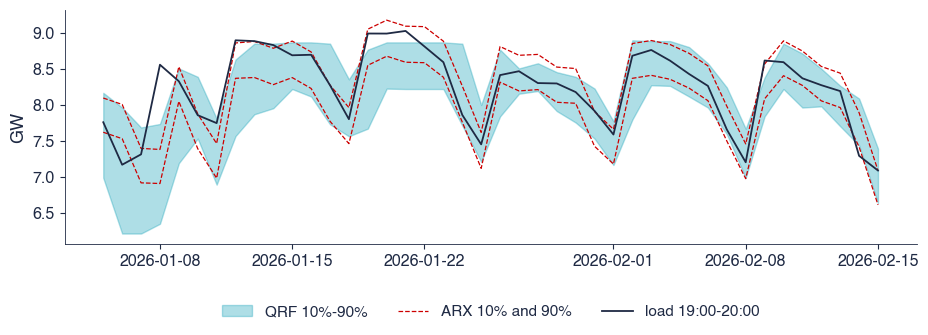

{'QRF': {'pin': 0.07854574016022292, 'cov': 0.8667711598746082, 'mae': 0.19526555806532286, 'width': 0.7837461206896552}, 'ARX': {'pin': 0.07755303585778486, 'cov': 0.7758620689655172, 'mae': 0.1872297126486272, 'width': 0.5304179657560588}, 'dm': {'t': 0.3965002383036899, 'p': 0.6918688210252673}, 'days': 638}


In [20]:
# Solution
print(b5_qrf_peak(save_it=False))

**Interpretation of the result.** Equal scores: QRF bands are wider and over-cover, ARX bands are sharper.

## B6 [Proposed]: monotone boosting for the evening peak

**Question.** Does the monotone constraint cost accuracy at the evening peak? Model: B5.

1. MAE of both models and the DM test.
2. Decreasing steps of the partial dependence.
3. Interpretation.

**Report:** two MAE values, one DM statistic, two counts, one sentence.

In [ ]:
# Your code here


## B7 [Solved]: LSTM against HAR for the FTSE 100

**Question.** Does an LSTM forecast next-day realised variance better than HAR?

1. HAR and LSTM forecasts.
2. QLIKE and the ratio.
3. DM.
4. Interpretation.

**Report:** two losses, one ratio, one DM statistic, one sentence.

- One seed here (three on the slides).

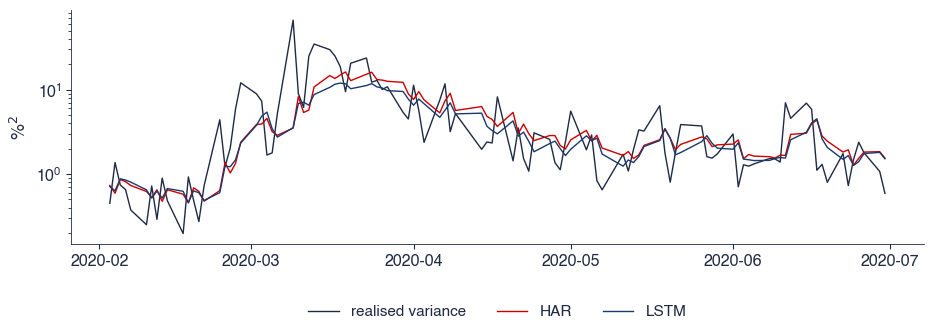

{'qlike': {'HAR': 0.24862422815944224, 'LSTM': 0.2477564420351885}, 'rel': 0.9965096477898476, 'dm': {'t': -0.4351907258693462, 'p': 0.6634544462429657}, 'T': 3085, 'start': '2009-12-08', 'end': '2022-02-25', 'seeds': 1}


In [22]:
# Solution
print(b7_lstm_ftse(save_it=False, seeds=(0,)))

**Interpretation of the result.** The LSTM is indistinguishable from HAR.

## B8 [Proposed]: DLinear and N-BEATS on 100 M4 hourly series

**Question.** Does a global N-BEATS still beat the benchmarks with 100 series? Model: B7.

1. Naive 2, seasonal naive, DLinear, N-BEATS.
2. sMAPE, MASE, OWA.
3. Interpretation.

**Report:** twelve numbers, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: deep learners against HAR for crypto-assets

**Question.** Do learners beat HAR for Bitcoin and Ether realised variance? Model: B7.

1. A five-line pre-registration.
2. HAR, MLP and boosting at h = 1 and 5; QLIKE ratios and DM.
3. Interpretation.

**Report:** a five-line plan, eight ratios with p-values, a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) random K-fold cross-validation is never valid for time series;
- (b) a TCN with kernel 3 and dilations 1, 2, 4, 8 (two convolutions per block) sees the last 31 hours;
- (c) with enough trees, bagging drives the variance of the forecast to zero;
- (d) LSTMs never suffer from vanishing gradients, thanks to their gates;
- (e) Zeng et al. (2023) proved that every Transformer is worse than a linear model;
- (f) the patch with the largest attention weight is the one the forecast depends on most;
- (g) Shapley values of all features sum to the prediction minus the average prediction over the background.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** seven verdicts with one line of justification each.

In [ ]:
# Your code here
